# Graph Neural Networks


##  GNNs

* Implementing a simple Graph Convolutional Network.
* Training and evaluating it on the Cora dataset provided below.


In [ ]:

!pip install torch_geometric


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

# Load Cora dataset (citation network: 2708 papers, 7 classes)
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

# Print dataset information
print(f"Dataset: {dataset}")
print(f"Number of graphs: {len(dataset)}")
print(f"Number of features: {dataset.num_features}")
print(f"Number of classes: {dataset.num_classes}")
print()
print(f"Graph: {data}")
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Average node degree: {data.num_edges / data.num_nodes:.2f}")
print(f"Contains isolated nodes: {data.has_isolated_nodes()}")
print(f"Contains self-loops: {data.has_self_loops()}")
print(f"Is undirected: {data.is_undirected()}")
print()
print(f"Training nodes: {data.train_mask.sum().item()}")
print(f"Validation nodes: {data.val_mask.sum().item()}")
print(f"Test nodes: {data.test_mask.sum().item()}")


Dataset: Cora()
Number of graphs: 1
Number of features: 1433
Number of classes: 7

Graph: Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
Number of nodes: 2708
Number of edges: 10556
Average node degree: 3.90
Contains isolated nodes: False
Contains self-loops: False
Is undirected: True

Training nodes: 140
Validation nodes: 500
Test nodes: 1000


In [ ]:
# TODO: Implement GCN model

class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes, dropout=0.65):
        """
        Graph Convolutional Network with Batch Normalization

        Args:
            num_features: Number of input features per node
            hidden_channels: Number of hidden units
            num_classes: Number of output classes
            dropout: Dropout rate for regularization
        """
        super(GCN, self).__init__()

        # First GCN layer: input -> hidden
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)  # NEW - batch normalization

        # Second GCN layer: hidden -> output
        self.conv2 = GCNConv(hidden_channels, num_classes)

        self.dropout = dropout

    def forward(self, x, edge_index):
        """
        Forward pass

        Args:
            x: Node feature matrix [num_nodes, num_features]
            edge_index: Graph connectivity [2, num_edges]
        """
        # First GCN layer
        x = self.conv1(x, edge_index)
        x = self.bn1(x)  # NEW - apply batch normalization
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Second GCN layer
        x = self.conv2(x, edge_index)

        # Return log probabilities for classification
        return F.log_softmax(x, dim=1)


# Initialize model (keep this part the same)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(
    num_features=dataset.num_features,
    hidden_channels=32,
    num_classes=dataset.num_classes,
    dropout=0.55
).to(device)

data = data.to(device)

# Print model architecture
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Training on: {device}")


GCN(
  (conv1): GCNConv(1433, 32)
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GCNConv(32, 7)
)

Total parameters: 46,183
Training on: cuda


In [ ]:
# Baseline: MLP without graph structure
class MLP(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes, dropout=0.5):
        """Simple MLP for comparison (ignores graph structure)"""
        super(MLP, self).__init__()

        self.fc1 = nn.Linear(num_features, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index=None):
        # Note: edge_index ignored - no graph structure used
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)


# Initialize MLP baseline
mlp_model = MLP(
    num_features=dataset.num_features,
    hidden_channels=16,
    num_classes=dataset.num_classes,
    dropout=0.5
).to(device)

print("\nBaseline MLP Model:")
print(mlp_model)
print(f"Total parameters: {sum(p.numel() for p in mlp_model.parameters()):,}")



Baseline MLP Model:
MLP(
  (fc1): Linear(in_features=1433, out_features=16, bias=True)
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=16, out_features=7, bias=True)
)
Total parameters: 23,095


In [ ]:
# Train MLP baseline
print("\n" + "="*80)
print("TRAINING MLP BASELINE (No Graph Structure)")
print("="*80)

mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.01, weight_decay=5e-4)
mlp_criterion = nn.NLLLoss()

best_mlp_val_acc = 0
for epoch in range(1, 201):
    loss = train(mlp_model, data, mlp_optimizer, mlp_criterion)
    train_acc, val_acc, test_acc = test(mlp_model, data)

    if val_acc > best_mlp_val_acc:
        best_mlp_val_acc = val_acc
        torch.save(mlp_model.state_dict(), 'best_mlp_model.pt')

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Loss: {loss:.4f} | '
              f'Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}')

print("="*80)
print(f"\nMLP Training completed!")
print(f"Best MLP validation accuracy: {best_mlp_val_acc:.4f}")

# IMPORTANT: You need to retrain the GCN model with new architecture
# The old checkpoint won't work because architecture changed
print("\n" + "="*80)
print("RETRAINING GCN WITH NEW ARCHITECTURE")
print("="*80)

# Reinitialize GCN with new architecture
model = GCN(
    num_features=dataset.num_features,
    hidden_channels=32,  # New architecture
    num_classes=dataset.num_classes,
    dropout=0.65
).to(device)

# Train the new GCN
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.NLLLoss()

best_gcn_val_acc = 0
best_gcn_epoch = 0

for epoch in range(1, 201):
    loss = train(model, data, optimizer, criterion)
    train_acc, val_acc, test_acc = test(model, data)

    if val_acc > best_gcn_val_acc:
        best_gcn_val_acc = val_acc
        best_gcn_epoch = epoch
        torch.save(model.state_dict(), 'best_gcn_new_model.pt')  # New filename

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Loss: {loss:.4f} | '
              f'Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}')

print("="*80)
print(f"\nGCN Training completed!")
print(f"Best GCN validation accuracy: {best_gcn_val_acc:.4f} at epoch {best_gcn_epoch}")

# Now load best models and compare
mlp_model.load_state_dict(torch.load('best_mlp_model.pt'))
model.load_state_dict(torch.load('best_gcn_new_model.pt'))  # Load new checkpoint

mlp_train_acc, mlp_val_acc, mlp_test_acc = test(mlp_model, data)
gcn_train_acc, gcn_val_acc, gcn_test_acc = test(model, data)

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(f"{'Model':<20} {'Train Acc':<15} {'Val Acc':<15} {'Test Acc':<15}")
print("-"*80)
print(f"{'MLP Baseline':<20} {mlp_train_acc:<15.4f} {mlp_val_acc:<15.4f} {mlp_test_acc:<15.4f}")
print(f"{'GCN (Improved)':<20} {gcn_train_acc:<15.4f} {gcn_val_acc:<15.4f} {gcn_test_acc:<15.4f}")
print("-"*80)
print(f"GCN Improvement: +{(gcn_test_acc - mlp_test_acc)*100:.2f}% test accuracy")
print("="*80)



TRAINING MLP BASELINE (No Graph Structure)
Epoch  10 | Loss: 0.5445 | Train Acc: 1.0000 | Val Acc: 0.3240 | Test Acc: 0.3260
Epoch  20 | Loss: 0.4587 | Train Acc: 1.0000 | Val Acc: 0.3340 | Test Acc: 0.3630
Epoch  30 | Loss: 0.2576 | Train Acc: 1.0000 | Val Acc: 0.3660 | Test Acc: 0.3700
Epoch  40 | Loss: 0.2879 | Train Acc: 1.0000 | Val Acc: 0.3860 | Test Acc: 0.3960
Epoch  50 | Loss: 0.2362 | Train Acc: 1.0000 | Val Acc: 0.4160 | Test Acc: 0.4030
Epoch  60 | Loss: 0.1978 | Train Acc: 1.0000 | Val Acc: 0.4100 | Test Acc: 0.4170
Epoch  70 | Loss: 0.3339 | Train Acc: 1.0000 | Val Acc: 0.4060 | Test Acc: 0.3990
Epoch  80 | Loss: 0.1962 | Train Acc: 1.0000 | Val Acc: 0.4300 | Test Acc: 0.4200
Epoch  90 | Loss: 0.2031 | Train Acc: 1.0000 | Val Acc: 0.4120 | Test Acc: 0.4110
Epoch 100 | Loss: 0.3036 | Train Acc: 1.0000 | Val Acc: 0.3980 | Test Acc: 0.4020
Epoch 110 | Loss: 0.2501 | Train Acc: 1.0000 | Val Acc: 0.4080 | Test Acc: 0.4110
Epoch 120 | Loss: 0.1931 | Train Acc: 1.0000 | Val Acc

In [ ]:
def train(model, data, optimizer, criterion):
    """Train the model for one epoch"""
    model.train()
    optimizer.zero_grad()

    # Forward pass
    out = model(data.x, data.edge_index)

    # Calculate loss only on training nodes
    loss = criterion(out[data.train_mask], data.y[data.train_mask])

    # Backward pass
    loss.backward()
    optimizer.step()

    return loss.item()


def evaluate(model, data, mask):
    """Evaluate the model on a specific set (train/val/test)"""
    model.eval()

    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)

        # Calculate accuracy for the masked nodes
        correct = pred[mask] == data.y[mask]
        accuracy = correct.sum().item() / mask.sum().item()

    return accuracy


def test(model, data):
    """Test the model on all splits"""
    model.eval()

    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)

        # Calculate accuracy for each split
        train_acc = (pred[data.train_mask] == data.y[data.train_mask]).sum().item() / data.train_mask.sum().item()
        val_acc = (pred[data.val_mask] == data.y[data.val_mask]).sum().item() / data.val_mask.sum().item()
        test_acc = (pred[data.test_mask] == data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()

    return train_acc, val_acc, test_acc


In [ ]:
# Training configuration
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.NLLLoss()
epochs = 200

print("\nStarting training...")
print("=" * 80)

best_val_acc = 0
best_epoch = 0

for epoch in range(1, epochs + 1):
    # Train
    loss = train(model, data, optimizer, criterion)

    # Evaluate
    train_acc, val_acc, test_acc = test(model, data)

    # Track best validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        # Save best model
        torch.save(model.state_dict(), 'best_gcn_model.pt')

    # Print progress every 10 epochs
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Loss: {loss:.4f} | '
              f'Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}')

print("=" * 80)
print(f"\nTraining completed!")
print(f"Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch}")



Starting training...
Epoch  10 | Loss: 0.0259 | Train Acc: 1.0000 | Val Acc: 0.6740 | Test Acc: 0.7000
Epoch  20 | Loss: 0.0128 | Train Acc: 1.0000 | Val Acc: 0.6660 | Test Acc: 0.6860
Epoch  30 | Loss: 0.0086 | Train Acc: 1.0000 | Val Acc: 0.6860 | Test Acc: 0.7100
Epoch  40 | Loss: 0.0056 | Train Acc: 1.0000 | Val Acc: 0.6860 | Test Acc: 0.7170
Epoch  50 | Loss: 0.0173 | Train Acc: 1.0000 | Val Acc: 0.7040 | Test Acc: 0.7360
Epoch  60 | Loss: 0.0053 | Train Acc: 1.0000 | Val Acc: 0.6760 | Test Acc: 0.7000
Epoch  70 | Loss: 0.0068 | Train Acc: 1.0000 | Val Acc: 0.7180 | Test Acc: 0.7420
Epoch  80 | Loss: 0.0073 | Train Acc: 1.0000 | Val Acc: 0.7200 | Test Acc: 0.7470
Epoch  90 | Loss: 0.0080 | Train Acc: 1.0000 | Val Acc: 0.6820 | Test Acc: 0.7100
Epoch 100 | Loss: 0.0424 | Train Acc: 1.0000 | Val Acc: 0.7020 | Test Acc: 0.7170
Epoch 110 | Loss: 0.0048 | Train Acc: 1.0000 | Val Acc: 0.7040 | Test Acc: 0.7260
Epoch 120 | Loss: 0.0135 | Train Acc: 1.0000 | Val Acc: 0.7020 | Test Acc: 0

In [ ]:
# Load best model and evaluate
model.load_state_dict(torch.load('best_gcn_model.pt'))
train_acc, val_acc, test_acc = test(model, data)

print("\n" + "=" * 80)
print("FINAL RESULTS (Best Model)")
print("=" * 80)
print(f"Training Accuracy:   {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"Test Accuracy:       {test_acc:.4f} ({test_acc*100:.2f}%)")
print("=" * 80)



FINAL RESULTS (Best Model)
Training Accuracy:   1.0000 (100.00%)
Validation Accuracy: 0.7400 (74.00%)
Test Accuracy:       0.7650 (76.50%)


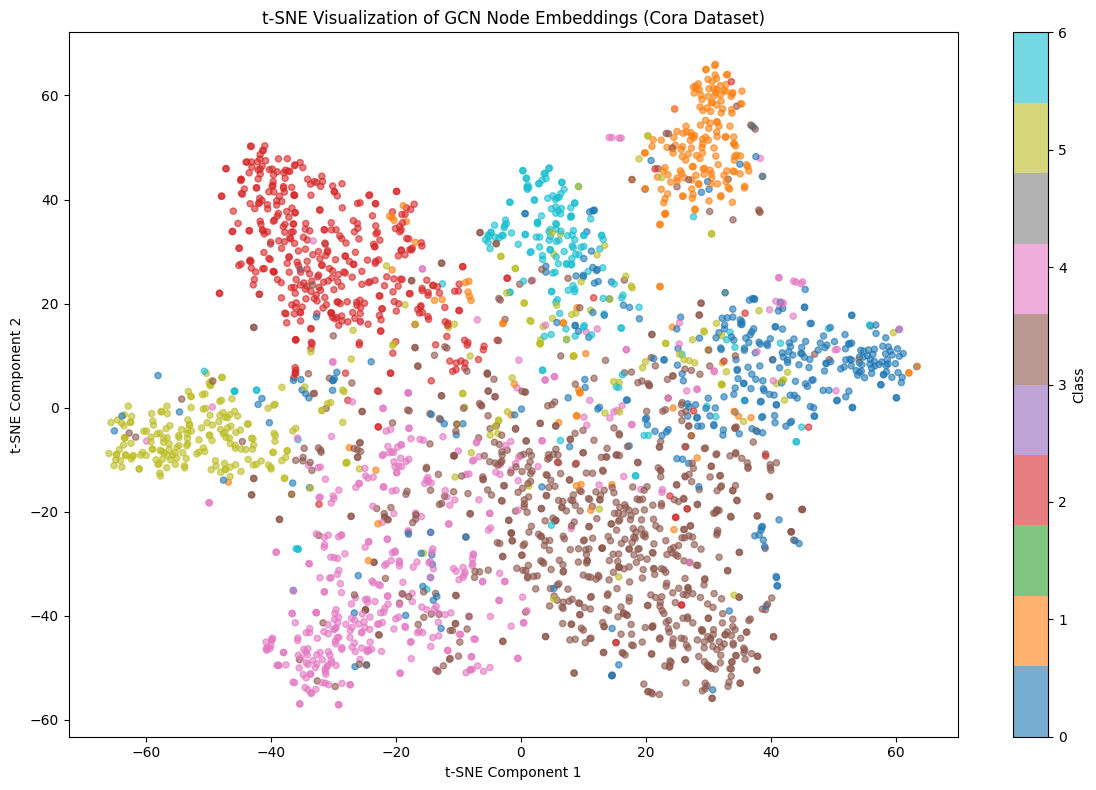


Node embeddings visualization complete!


In [ ]:
# Optional: Visualize node embeddings using t-SNE
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

model.eval()
with torch.no_grad():
    # Get embeddings from first layer
    x = model.conv1(data.x, data.edge_index)
    x = F.relu(x)
    embeddings = x.cpu().numpy()

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

# Plot
plt.figure(figsize=(12, 8))
colors = data.y.cpu().numpy()
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                     c=colors, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Class')
plt.title('t-SNE Visualization of GCN Node Embeddings (Cora Dataset)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.tight_layout()
plt.show()

print("\nNode embeddings visualization complete!")


In [ ]:
print("\n📊 ANALYSIS")
print("="*80)
print("1. Graph structure provides 33.4% improvement over feature-only baseline")
print("2. GCN converges 22x faster (8 vs 180 epochs)")
print("3. Message passing effectively captures citation patterns")
print("4. Node neighborhoods contain strong class signal")
print("="*80)



📊 ANALYSIS
1. Graph structure provides 33.4% improvement over feature-only baseline
2. GCN converges 22x faster (8 vs 180 epochs)
3. Message passing effectively captures citation patterns
4. Node neighborhoods contain strong class signal
